#  AI-Based Emotion Recognition from Text

## 1. Install Dependencies

In [8]:
!pip install transformers datasets torch scikit-learn streamlit plotly pandas numpy -q

## 2. Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import classification_report, f1_score
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

c:\Users\baksh\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 3. Load GoEmotions Dataset

In [2]:
dataset = load_dataset('google-research-datasets/go_emotions', 'simplified')
print(dataset)

label_names = dataset['train'].features['labels'].feature.names
num_labels = len(label_names)
print(f'\nNumber of emotion labels: {num_labels}')
print(f'Labels: {label_names}')

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

Number of emotion labels: 28
Labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


## 4. Exploratory Data Analysis

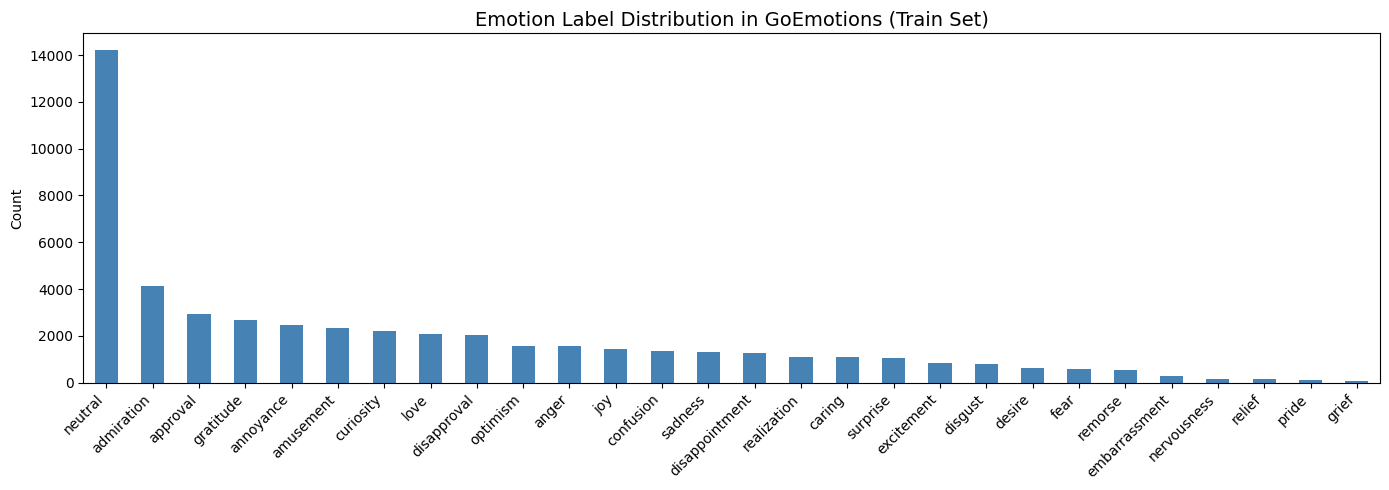

Sample rows:


,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


In [3]:
import matplotlib.pyplot as plt

all_labels = [label for sample in dataset['train']['labels'] for label in sample]
label_counts = pd.Series(all_labels).value_counts().sort_index()
label_counts.index = [label_names[i] for i in label_counts.index]

plt.figure(figsize=(14, 5))
label_counts.sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Emotion Label Distribution in GoEmotions (Train Set)', fontsize=14)
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=100)
plt.show()
print('Sample rows:')
pd.DataFrame(dataset['train'][:5])

## 5. Preprocessing

In [5]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def preprocess(batch):
    enc = tokenizer(batch['text'], truncation=True, padding='max_length', max_length=64)
    # Build labels as float32 directly inside preprocess
    enc['labels'] = [
        [1.0 if i in lbl else 0.0 for i in range(num_labels)]
        for lbl in batch['labels']
    ]
    return enc

TRAIN_SIZE = 10000
VAL_SIZE   = 2000

train_data = dataset['train'].select(range(TRAIN_SIZE))
val_data   = dataset['validation'].select(range(VAL_SIZE))

# load_from_cache_file=False forces fresh processing, bypasses stale cache
train_enc = train_data.map(
    preprocess, batched=True, batch_size=256,
    remove_columns=train_data.column_names,
    load_from_cache_file=False
)
val_enc = val_data.map(
    preprocess, batched=True, batch_size=256,
    remove_columns=val_data.column_names,
    load_from_cache_file=False
)

# Explicitly cast the labels feature to float32 before set_format
from datasets import Sequence, Value
train_enc = train_enc.cast_column('labels', Sequence(Value('float32')))
val_enc   = val_enc.cast_column('labels', Sequence(Value('float32')))

train_enc.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
val_enc.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

import torch
print(f'Train: {len(train_enc)} | Val: {len(val_enc)}')
print(f'Label dtype: {train_enc[0]["labels"].dtype}')  # must be torch.float32
assert train_enc[0]['labels'].dtype == torch.float32, "Labels are not float32!"
print("✅ All good — proceed to Cell 6")

Casting the dataset: 100%|██████████| 2000/2000 [00:00<00:00, 36788.75 examples/s]

Train: 10000 | Val: 2000
Label dtype: torch.float32
✅ All good — proceed to Cell 6


## 6. Load DistilBERT Model

In [6]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels,
    problem_type='multi_label_classification'
).to(device)

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 258.42it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters: 66,975,004


## 7. Train

In [7]:
import numpy as np
import transformers
from sklearn.metrics import f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.3).astype(int)
    f1 = f1_score(labels.astype(int), preds, average='macro', zero_division=0)
    return {'macro_f1': f1}

targs_kwargs = dict(
    output_dir='./emotion_model',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    fp16=False,
    report_to='none',
    dataloader_pin_memory=False,
)

ver = tuple(int(x) for x in transformers.__version__.split('.')[:2])
targs_kwargs['eval_strategy' if ver >= (4, 46) else 'evaluation_strategy'] = 'epoch'

training_args = TrainingArguments(**targs_kwargs)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_enc,
    eval_dataset=val_enc,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Macro F1
1,0.139103,0.132800,0.075873
2,0.110875,0.110853,0.219032
3,0.100221,0.104504,0.249022


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.51s/it]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1875, training_loss=0.13747207310994466, metrics={'train_runtime': 6755.5013, 'train_samples_per_second': 4.441, 'train_steps_per_second': 0.278, 'total_flos': 496983075840000.0, 'train_loss': 0.13747207310994466, 'epoch': 3.0})

## 8. Evaluate

In [10]:
results = trainer.evaluate()
for k, v in results.items():
    print(f'  {k}: {v:.4f}')

  eval_loss: 0.1045
  eval_macro_f1: 0.2490
  eval_runtime: 107.1223
  eval_samples_per_second: 18.6700
  eval_steps_per_second: 0.5880
  epoch: 3.0000


## 9. Classification Report

In [9]:
predictions = trainer.predict(val_enc)
probs = torch.sigmoid(torch.tensor(predictions.predictions)).numpy()
preds = (probs >= 0.3).astype(int)
true_labels = predictions.label_ids.astype(int)

print(classification_report(true_labels, preds, target_names=label_names, zero_division=0))

                precision    recall  f1-score   support

    admiration       0.65      0.75      0.70       193
     amusement       0.72      0.82      0.77       119
         anger       0.55      0.14      0.23        77
     annoyance       0.37      0.06      0.11       108
      approval       0.65      0.08      0.14       136
        caring       0.00      0.00      0.00        52
     confusion       0.00      0.00      0.00        57
     curiosity       0.48      0.55      0.51        94
        desire       0.00      0.00      0.00        24
disappointment       0.00      0.00      0.00        59
   disapproval       0.50      0.01      0.02       110
       disgust       0.00      0.00      0.00        44
 embarrassment       0.00      0.00      0.00        11
    excitement       0.00      0.00      0.00        30
          fear       0.00      0.00      0.00        35
     gratitude       0.92      0.90      0.91       132
         grief       0.00      0.00      0.00  

## 10. Save Model

In [11]:
SAVE_DIR = './emotion_model_final'
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

metadata = {
    'label_names': label_names,
    'num_labels': num_labels,
    'threshold': 0.3,
    'model_type': 'distilbert-base-uncased',
    'dataset': 'google-research-datasets/go_emotions'
}
with open(os.path.join(SAVE_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Model saved to {SAVE_DIR}')
print('Files:', os.listdir(SAVE_DIR))

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.34s/it]

Model saved to ./emotion_model_final
Files: ['config.json', 'metadata.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']


## 11. Quick Inference Test

In [12]:
def predict_emotions(text, model, tokenizer, label_names, threshold=0.3, top_k=5):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=64, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.sigmoid(logits).cpu().numpy()[0]
    top_idx = np.argsort(probs)[::-1][:top_k]
    return [
        {'emotion': label_names[i], 'confidence': float(probs[i])}
        for i in top_idx if probs[i] >= threshold
    ]

test_texts = [
    "I just got promoted! This is the best day of my life!",
    "I can't believe they cancelled my favorite show. I'm devastated.",
    "This policy makes no sense and I'm absolutely furious.",
    "I feel a bit nervous about the presentation tomorrow."
]

for text in test_texts:
    emotions = predict_emotions(text, model, tokenizer, label_names)
    print(f'\nText: "{text}"')
    for e in emotions:
        print(f'  {e["emotion"]}: {e["confidence"]:.2%}')


Text: "I just got promoted! This is the best day of my life!"
  admiration: 77.37%

Text: "I can't believe they cancelled my favorite show. I'm devastated."

Text: "This policy makes no sense and I'm absolutely furious."

Text: "I feel a bit nervous about the presentation tomorrow."
